Attempting to replicate the results from Gelli+24

In [112]:
from escripts import eMCMC
import importlib
from escripts import eplots
Plotting = eplots.Plotting()

In [113]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [114]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt',
                       '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt', 
                      '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']

In [115]:
test_data = eMCMC.read_data(file_names)

In [116]:
best_fits = [[0.69, 0.01, -0.36, 0.11, 12.08, 0.07, -0.91, -0.01, 0.55, -0.05, -0.14]]

In [122]:
importlib.reload(eplots)
Plotting = eplots.Plotting()

/Users/eb35267/Desktop/code/home/escripts/eplots.py:168: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')
/Users/eb35267/Desktop/code/home/escripts/eplots.py:223: SyntaxWarning: invalid escape sequence '\c'
  zorder = 1)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:229: SyntaxWarning: invalid escape sequence '\s'
  ax[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the


working


/Users/eb35267/Desktop/code/home/escripts/eplots.py:223: RuntimeWarning: invalid value encountered in log10
  ax[i].plot(plot_xdat, np.log10(UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,sample)), label = f'{label}, $\chi^2 = {chi2:.0f}$',


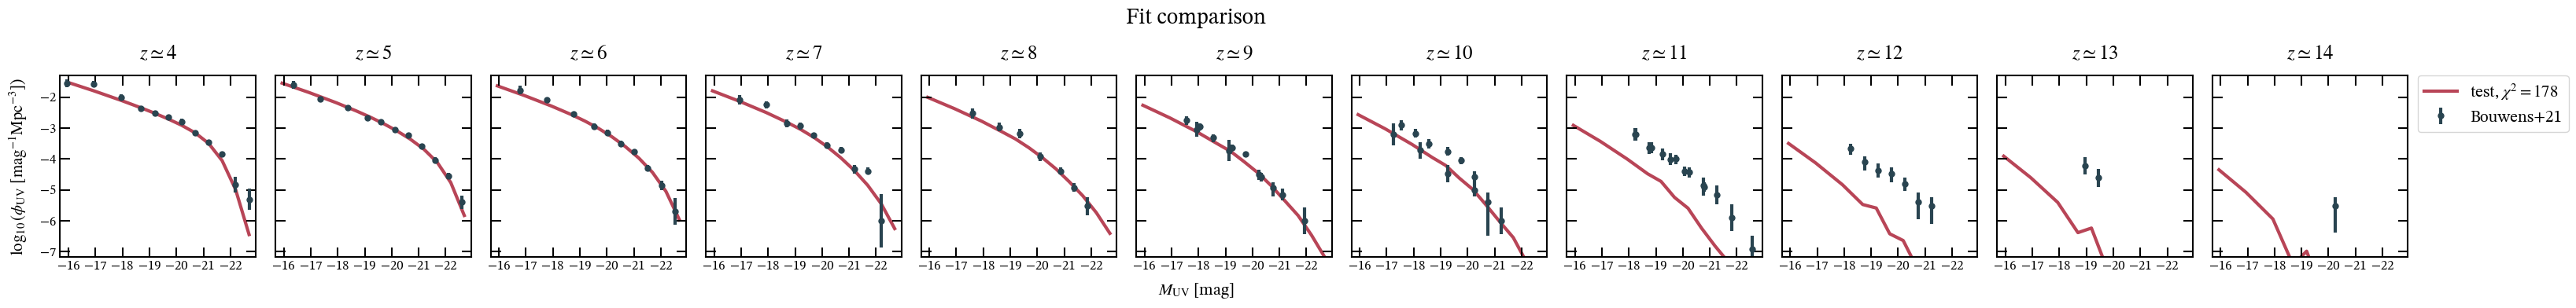

In [124]:
test_plot = Plotting.compare_fits(file_names, best_fits, ['test'])

In [160]:
def read_data(file_names): 
    """
    Read in data and organize it by redshift
    Inputs:
        file_names [list of strs]: file names to read data from
    Returns:
        data, organized by redshift
    """
    all_data = []
    for fn in file_names:
        all_data.append(np.loadtxt(fn, skiprows=2, unpack = True))
                        
    redshifts = np.unique(np.concatenate([data[0] for data in all_data])) # Get a list of all redshifts that exist within the files
    dredshifts = np.ones_like(redshifts)/2. #approximate, there are true window functions to use

    # Organize data by redshift
    sorted_data = []
    #format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 
    
    for iz,z in enumerate(redshifts):
        z_separated = []
        for data in all_data:
            zlistindex = data[0] == 1.0*z
            datarr = [z,dredshifts[iz], data[1][zlistindex], data[3][zlistindex], np.abs(data[4:6].reshape(-1,2)[zlistindex]), 
                      # Read upper and lower sigma. Use absolute value because the lower error bar is given as negative (centered on ydat)
                      data[2][zlistindex]]
            z_separated.append(datarr)
        sorted_data.append(z_separated)

    return sorted_data

In [161]:
test = read_data(file_names)

In [157]:
test[0][0]

[4.0,
 0.5,
 array([-22.69, -22.19, -21.69, -21.19, -20.69, -20.19, -19.69, -19.19,
        -18.69, -17.94, -16.94, -15.94]),
 array([5.000e-06, 1.500e-05, 1.440e-04, 3.440e-04, 6.980e-04, 1.624e-03,
        2.276e-03, 3.056e-03, 4.371e-03, 1.016e-02, 2.742e-02, 2.882e-02]),
 array([[4.00e-06, 9.00e-06],
        [2.20e-05, 3.80e-05],
        [6.80e-05, 1.31e-04],
        [1.99e-04, 3.88e-04],
        [6.89e-04, 9.20e-04],
        [3.44e-03, 8.74e-03],
        [1.00e-06, 2.00e-06],
        [7.00e-06, 1.30e-05],
        [2.40e-05, 4.40e-05],
        [6.70e-05, 1.56e-04],
        [3.46e-04, 5.20e-04],
        [1.54e-03, 7.34e-03]]),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])]

In [174]:
reduced_data = []
for test_i in test:
    z = test_i[0][0]
    dz = test_i[0][1]
    MUVs = np.concatenate([t[2] for t in test_i])
    phis = np.concatenate([t[3] for t in test_i])
    dphi = np.hstack((np.concatenate([t[4][:,0] for t in test_i]).reshape(-1,1), np.concatenate([t[4][:,0] for t in test_i]).reshape(-1,1)))
    dMUV = np.concatenate([t[5] for t in test_i])
    reduced_data.append([z, dz, MUVs, phis, dphi, dMUV])

In [175]:
reduced_data

[[4.0,
  0.5,
  array([-22.69, -22.19, -21.69, -21.19, -20.69, -20.19, -19.69, -19.19,
         -18.69, -17.94, -16.94, -15.94]),
  array([5.000e-06, 1.500e-05, 1.440e-04, 3.440e-04, 6.980e-04, 1.624e-03,
         2.276e-03, 3.056e-03, 4.371e-03, 1.016e-02, 2.742e-02, 2.882e-02]),
  array([[4.00e-06, 4.00e-06],
         [2.20e-05, 2.20e-05],
         [6.80e-05, 6.80e-05],
         [1.99e-04, 1.99e-04],
         [6.89e-04, 6.89e-04],
         [3.44e-03, 3.44e-03],
         [1.00e-06, 1.00e-06],
         [7.00e-06, 7.00e-06],
         [2.40e-05, 2.40e-05],
         [6.70e-05, 6.70e-05],
         [3.46e-04, 3.46e-04],
         [1.54e-03, 1.54e-03]]),
  array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])],
 [5.0,
  0.5,
  array([-23.11, -22.61, -22.11, -21.61, -21.11, -20.61, -20.11, -19.61,
         -19.11, -18.36, -17.36, -16.36]),
  array([1.000e-06, 4.000e-06, 2.800e-05, 9.200e-05, 2.620e-04, 5.840e-04,
         8.790e-04, 1.594e-03, 2.159e-03, 4.620e-03, 8.780e-03, 2.5